# 29 — Figure 3: rights, criteria and social groups

Classical-Athens Figure 3 rebuilt from the corpus, in the exact style of athens-rights-figures/generate_figures.py. One data model — the table of which criteria each right requires — drives every panel: a group holds a right iff its criteria contain the right's required set; a criterion gates a right iff the right requires it. Every social group is its own node.

## 1. Configuration

In [1]:
import math
import subprocess
from io import BytesIO

import numpy as np
import pandas as pd
from PIL import Image as PILImage
from IPython.display import Image

FINAL = "../data/clean/final"
POLITY = "Classical Athens"

INK, GREY, LINE, EDGE = "#111111", "#7d7d7d", "#7d7d7d", "#9a9a9a"
FONT = "Helvetica Neue, Helvetica, Arial, sans-serif" 

In [2]:
# Six criterion columns: a positive trait a group must have; negatives disqualify a holder.
CRITERIA = [
    {"axis": "c_ownership_status", "label": "Free",        "positive": "free",     "negative": {"enslaved", "freed"}},
    {"axis": "c_ancestry",         "label": "Native-born", "positive": "native",   "negative": {"foreign"}},
    {"axis": "c_residence",        "label": "Resident",    "positive": "resident", "negative": {"non_resident", "foreign"}},
    {"axis": "c_sex",              "label": "Male",        "positive": "male",     "negative": {"female"}},
    {"axis": "c_age",              "label": "Adult",       "positive": "adult",    "negative": {"minor", "child"}},
    {"axis": "c_wealth",           "label": "Wealthy",     "positive": "high",     "negative": {"low"}},
]
CRIT_ORDER = [c["label"] for c in CRITERIA]
CRIT_SPLIT = {"Native-born": ["Native-", "born"]}

RIGHTS_CATEGORIES = {
    "Political": ["Voting in the assembly", "Speaking in the assembly", "Eligibility for public office",
                  "Eligibility for jury service", "Deliberative authority"],
    "Legal": ["Right to a trial", "Protection from judicial torture",
              "Protection from private assault"],
    "Economic": ["Inheriting property", "Owning and retaining property",
                 "Right to engage in business", "Exemption from taxes"],
    "Religious & family": ["Participation in sacred rites", "Right to a dowry",
                           "Freedom of choice in marriage", "Right to marry a citizen"],
    "Military": ["Possession of arms", "Exemption from military service", "Eligibility for military command"],
}
RIGHT_NAMES = [r for rights in RIGHTS_CATEGORIES.values() for r in rights]
TYPES = list(RIGHTS_CATEGORIES)

In [3]:
# Social groups quoted in the corpus, as intersectional cells of the six criteria (each its
# own node). Population is an illustrative demographic prior, NOT corpus data.
GROUPS = {
    "Wealthy citizen man": {"Free", "Native-born", "Resident", "Male", "Adult", "Wealthy"},
    "Poor citizen man":    {"Free", "Native-born", "Resident", "Male", "Adult"},
    "Citizen youth":       {"Free", "Native-born", "Resident", "Male"},
    "Citizen woman":       {"Free", "Native-born", "Resident", "Adult"},
    "Wealthy metic":       {"Free", "Resident", "Male", "Adult", "Wealthy"},
    "Metic":               {"Free", "Resident", "Male", "Adult"},
    "Freedman":            {"Free", "Resident", "Male"},
    "Slave":               {"Resident"},
}
POPULATION = {
    "Wealthy citizen man": 30, "Poor citizen man": 110, "Citizen youth": 60, "Citizen woman": 140,
    "Wealthy metic": 18, "Metic": 55, "Freedman": 25, "Slave": 160,
}
GROUP_SPLIT = {
    "Wealthy citizen man": ["Wealthy", "citizen man"], "Poor citizen man": ["Poor", "citizen man"],
    "Citizen youth": ["Citizen", "youth"], "Citizen woman": ["Citizen", "woman"],
    "Wealthy metic": ["Wealthy", "metic"], "Metic": ["Metic"], "Freedman": ["Freedman"], "Slave": ["Slave"],
}
GNAMES = list(GROUPS)

## 2. Load data

In [4]:
matrix = pd.read_csv(f"{FINAL}/group_rights_matrix.tsv", sep="\t")
matrix = matrix[matrix["rule_polity"] == POLITY].copy()
print("rows (emic group instances):", matrix.shape[0], "| emic groups:", matrix["group_meta"].nunique())
matrix[["group_meta", "period", "c_sex", "c_age", "c_ownership_status",
        "c_ancestry", "c_residence", "c_wealth", "n_rules"]].head()

rows (emic group instances): 101 | emic groups: 64


,group_meta,period,c_sex,c_age,c_ownership_status,c_ancestry,c_residence,c_wealth,n_rules
0,Citizens,Late Classical (354–165 BCE),male,adult,free,native,resident,any,88
1,Citizens,Classical (500–360 BCE),male,adult,free,native,resident,any,85
2,The wealthy,Late Classical (354–165 BCE),any,adult,free,unspecified,resident,high,31
3,Slaves,Late Classical (354–165 BCE),any,any,enslaved,any,resident,low,22
4,The poor,Late Classical (354–165 BCE),any,any,free,unspecified,resident,low,22


## 3. The table — which criteria gate each right

A criterion is **required** for a right when either signal says so:

- **Holders** — every attested group holding the right shares the criterion's positive value and none carries a disqualifying value.
- **Explicit denials** — a group the corpus denies the right lacks the positive value (enslaved → Free, poor → Wealthy, foreigners → Native-born, women → Male), charged to the single most fundamental trait it lacks.

In [5]:
def holds_right(v): return str(v) in {"1", "1.0"}
def denied_right(v): return str(v) in {"0", "0.0"}

def most_fundamental_lacking(group_row):
    for crit in CRITERIA:
        if str(group_row[crit["axis"]]) in crit["negative"]:
            return crit["label"]
    return None

gate_rows, n_holders, n_deniers = {}, {}, {}
for right in RIGHT_NAMES:
    holders = matrix[matrix[right].map(holds_right)]
    deniers = matrix[matrix[right].map(denied_right)]
    n_holders[right], n_deniers[right] = len(holders), len(deniers)
    denial_labels = set(deniers.apply(most_fundamental_lacking, axis=1).dropna())
    gate_rows[right] = {
        crit["label"]: int(
            ((crit["positive"] in set(holders[crit["axis"]].dropna().astype(str)))
             and not (set(holders[crit["axis"]].dropna().astype(str)) & crit["negative"]))
            or crit["label"] in denial_labels)
        for crit in CRITERIA
    }

gate_required = pd.DataFrame(gate_rows).T.reindex(RIGHT_NAMES)[CRIT_ORDER]
assert (pd.Series(n_holders) > 0).all(), "every right must have an attested holder"


In [6]:
gate_table = gate_required.copy()
gate_table.insert(0, "n_deniers", pd.Series(n_deniers))
gate_table.insert(0, "n_holders", pd.Series(n_holders))
gate_table.insert(0, "category", [c for c, rs in RIGHTS_CATEGORIES.items() for _ in rs])
gate_table.index.name = "right"
gate_table

,category,n_holders,n_deniers,Free,Native-born,Resident,Male,Adult,Wealthy
right,,,,,,,,,
Voting in the assembly,Political,5,1,1,0,1,1,1,0
Speaking in the assembly,Political,7,6,1,1,1,0,1,0
Eligibility for public office,Political,9,10,1,1,1,1,1,1
Eligibility for jury service,Political,6,4,1,1,1,1,1,1
Deliberative authority,Political,6,4,1,1,1,1,1,0
Right to a trial,Legal,9,3,0,1,1,1,0,0
Protection from judicial torture,Legal,1,2,1,1,1,1,1,0
Protection from private assault,Legal,6,1,1,0,1,0,1,0
Inheriting property,Economic,7,3,1,1,1,1,0,0


## 4. Groups, their criteria, and the rights they hold

Each right's required criteria are read off the table. A group holds a right when its own criteria contain that set.

In [7]:
required_criteria = {
    right: {c for c in CRIT_ORDER if gate_required.loc[right, c] == 1}
    for right in RIGHT_NAMES
}
RIGHTS = [(cat, name, required_criteria[name])
          for cat, names in RIGHTS_CATEGORIES.items() for name in names]

def rights_held(group_criteria, names):
    return frozenset(r for r in names if required_criteria[r] <= group_criteria)

group_descriptions = pd.DataFrame({
    "criteria met": {g: " · ".join(c for c in CRIT_ORDER if c in crit) or "— (none)"
                     for g, crit in GROUPS.items()},
    "population": POPULATION,
    "rights held (of 20)": {g: len(rights_held(crit, RIGHT_NAMES)) for g, crit in GROUPS.items()},
})
group_descriptions

,criteria met,population,rights held (of 20)
Wealthy citizen man,Free · Native-born · Resident · Male · Adult ·...,30,19
Poor citizen man,Free · Native-born · Resident · Male · Adult,110,15
Citizen youth,Free · Native-born · Resident · Male,60,4
Citizen woman,Free · Native-born · Resident · Adult,140,6
Wealthy metic,Free · Resident · Male · Adult · Wealthy,18,3
Metic,Free · Resident · Male · Adult,55,3
Freedman,Free · Resident · Male,25,0
Slave,Resident,160,0


In [8]:
held_counts = pd.DataFrame({
    cat: {g: len(rights_held(crit, rs)) for g, crit in GROUPS.items()}
    for cat, rs in RIGHTS_CATEGORIES.items()
})
held_counts

,Political,Legal,Economic,Religious & family,Military
Wealthy citizen man,5,3,4,4,3
Poor citizen man,3,3,4,3,2
Citizen youth,0,1,2,1,0
Citizen woman,1,1,2,2,0
Wealthy metic,1,1,0,0,1
Metic,1,1,0,0,1
Freedman,0,0,0,0,0
Slave,0,0,0,0,0


## 5. Rendering helpers (reference SVG style)

In [9]:
def rights_of_type(t=None):
    return [i for i, r in enumerate(RIGHTS) if t is None or r[0] == t]

def held(critset, idxs):
    return frozenset(i for i in idxs if RIGHTS[i][2] <= critset)

def gated(crit, idxs):
    return frozenset(i for i in idxs if crit in RIGHTS[i][2])

def covering(items, hmap):
    edges = []
    for lo in items:
        for hi in items:
            if hmap[lo] < hmap[hi] and not any(
                n not in (lo, hi) and hmap[lo] < hmap[n] < hmap[hi] for n in items):
                edges.append((hi, lo))
    return edges

def svg(w, h, body, vx=0, vy=0):
    return (f'<svg xmlns="http://www.w3.org/2000/svg" width="{w:.0f}" height="{h:.0f}" '
            f'viewBox="{vx} {vy} {w:.0f} {h:.0f}" font-family="{FONT}" fill="{INK}">\n'
            f'<rect x="{vx}" y="{vy}" width="{w:.0f}" height="{h:.0f}" fill="#fff"/>\n{body}\n</svg>\n')

def node(cx, cy, r, lines, fs=11.5, stroke=1.5, bold=False, inside=False):
    out = [f'<circle cx="{cx:.1f}" cy="{cy:.1f}" r="{r:.1f}" fill="#f0f0f0" stroke="{INK}" stroke-width="{stroke}"/>']
    fw = ' font-weight="700"' if bold else ""
    line_h = fs + 1
    if inside:
        # centre the label lines vertically on the node
        ly = cy - (len(lines) - 1) * line_h / 2 + 0.34 * fs
        for ln in lines:
            out.append(f'<text x="{cx:.1f}" y="{ly:.1f}" font-size="{fs}"{fw} text-anchor="middle">{ln}</text>')
            ly += line_h
    else:
        # first line's box sits exactly at the node's bottom edge (font-size independent)
        ly = cy + r + fs - 1.5
        for ln in lines:
            wln = len(ln) * fs * 0.56
            out.append(f'<rect x="{cx-wln/2:.1f}" y="{ly-fs+1.5:.1f}" width="{wln:.1f}" height="{fs:.0f}" fill="#fff"/>')
            out.append(f'<text x="{cx:.1f}" y="{ly:.1f}" font-size="{fs}"{fw} text-anchor="middle">{ln}</text>')
            ly += line_h
    return "\n".join(out)

def link(p, q, pos):
    (x1, y1), (x2, y2) = pos[p], pos[q]
    return f'<line x1="{x1:.1f}" y1="{y1:.1f}" x2="{x2:.1f}" y2="{y2:.1f}" stroke="{LINE}" stroke-width="1"/>'

def png(markup, zoom=2):
    return subprocess.run(["rsvg-convert", "-z", str(zoom)], input=markup.encode(), capture_output=True).stdout

def type_panel(gx, top, title, items, hmap, radius, split, vs, xs_gap, hy_off=34, bold=False,
               label_fs=12.5, title_fs=14, label_inside=False):
    counts = sorted({len(hmap[n]) for n in items}, reverse=True)
    lvl = {c: i for i, c in enumerate(counts)}
    by = {}
    for n in items:
        by.setdefault(lvl[len(hmap[n])], []).append(n)
    maxk = max(len(v) for v in by.values())
    cx = gx + (maxk - 1) * xs_gap / 2
    pos = {}
    for L, ns in by.items():
        k = len(ns)
        for i, n in enumerate(ns):
            pos[n] = (cx + (i - (k - 1) / 2) * xs_gap, top + L * vs)
    body = [f'<text x="{cx:.1f}" y="{top-hy_off:.0f}" font-size="{title_fs}" font-weight="700" '
            f'text-anchor="middle">{title.replace("&", "&amp;")}</text>']
    for hi, lo in covering(items, hmap):
        body.append(link(hi, lo, pos))
    for n in items:
        body.append(node(*pos[n], radius(n), split(n), fs=label_fs, stroke=1.4, bold=bold,
                         inside=label_inside))
    return "\n".join(body), gx + maxk * xs_gap + 46

## 6. Figures

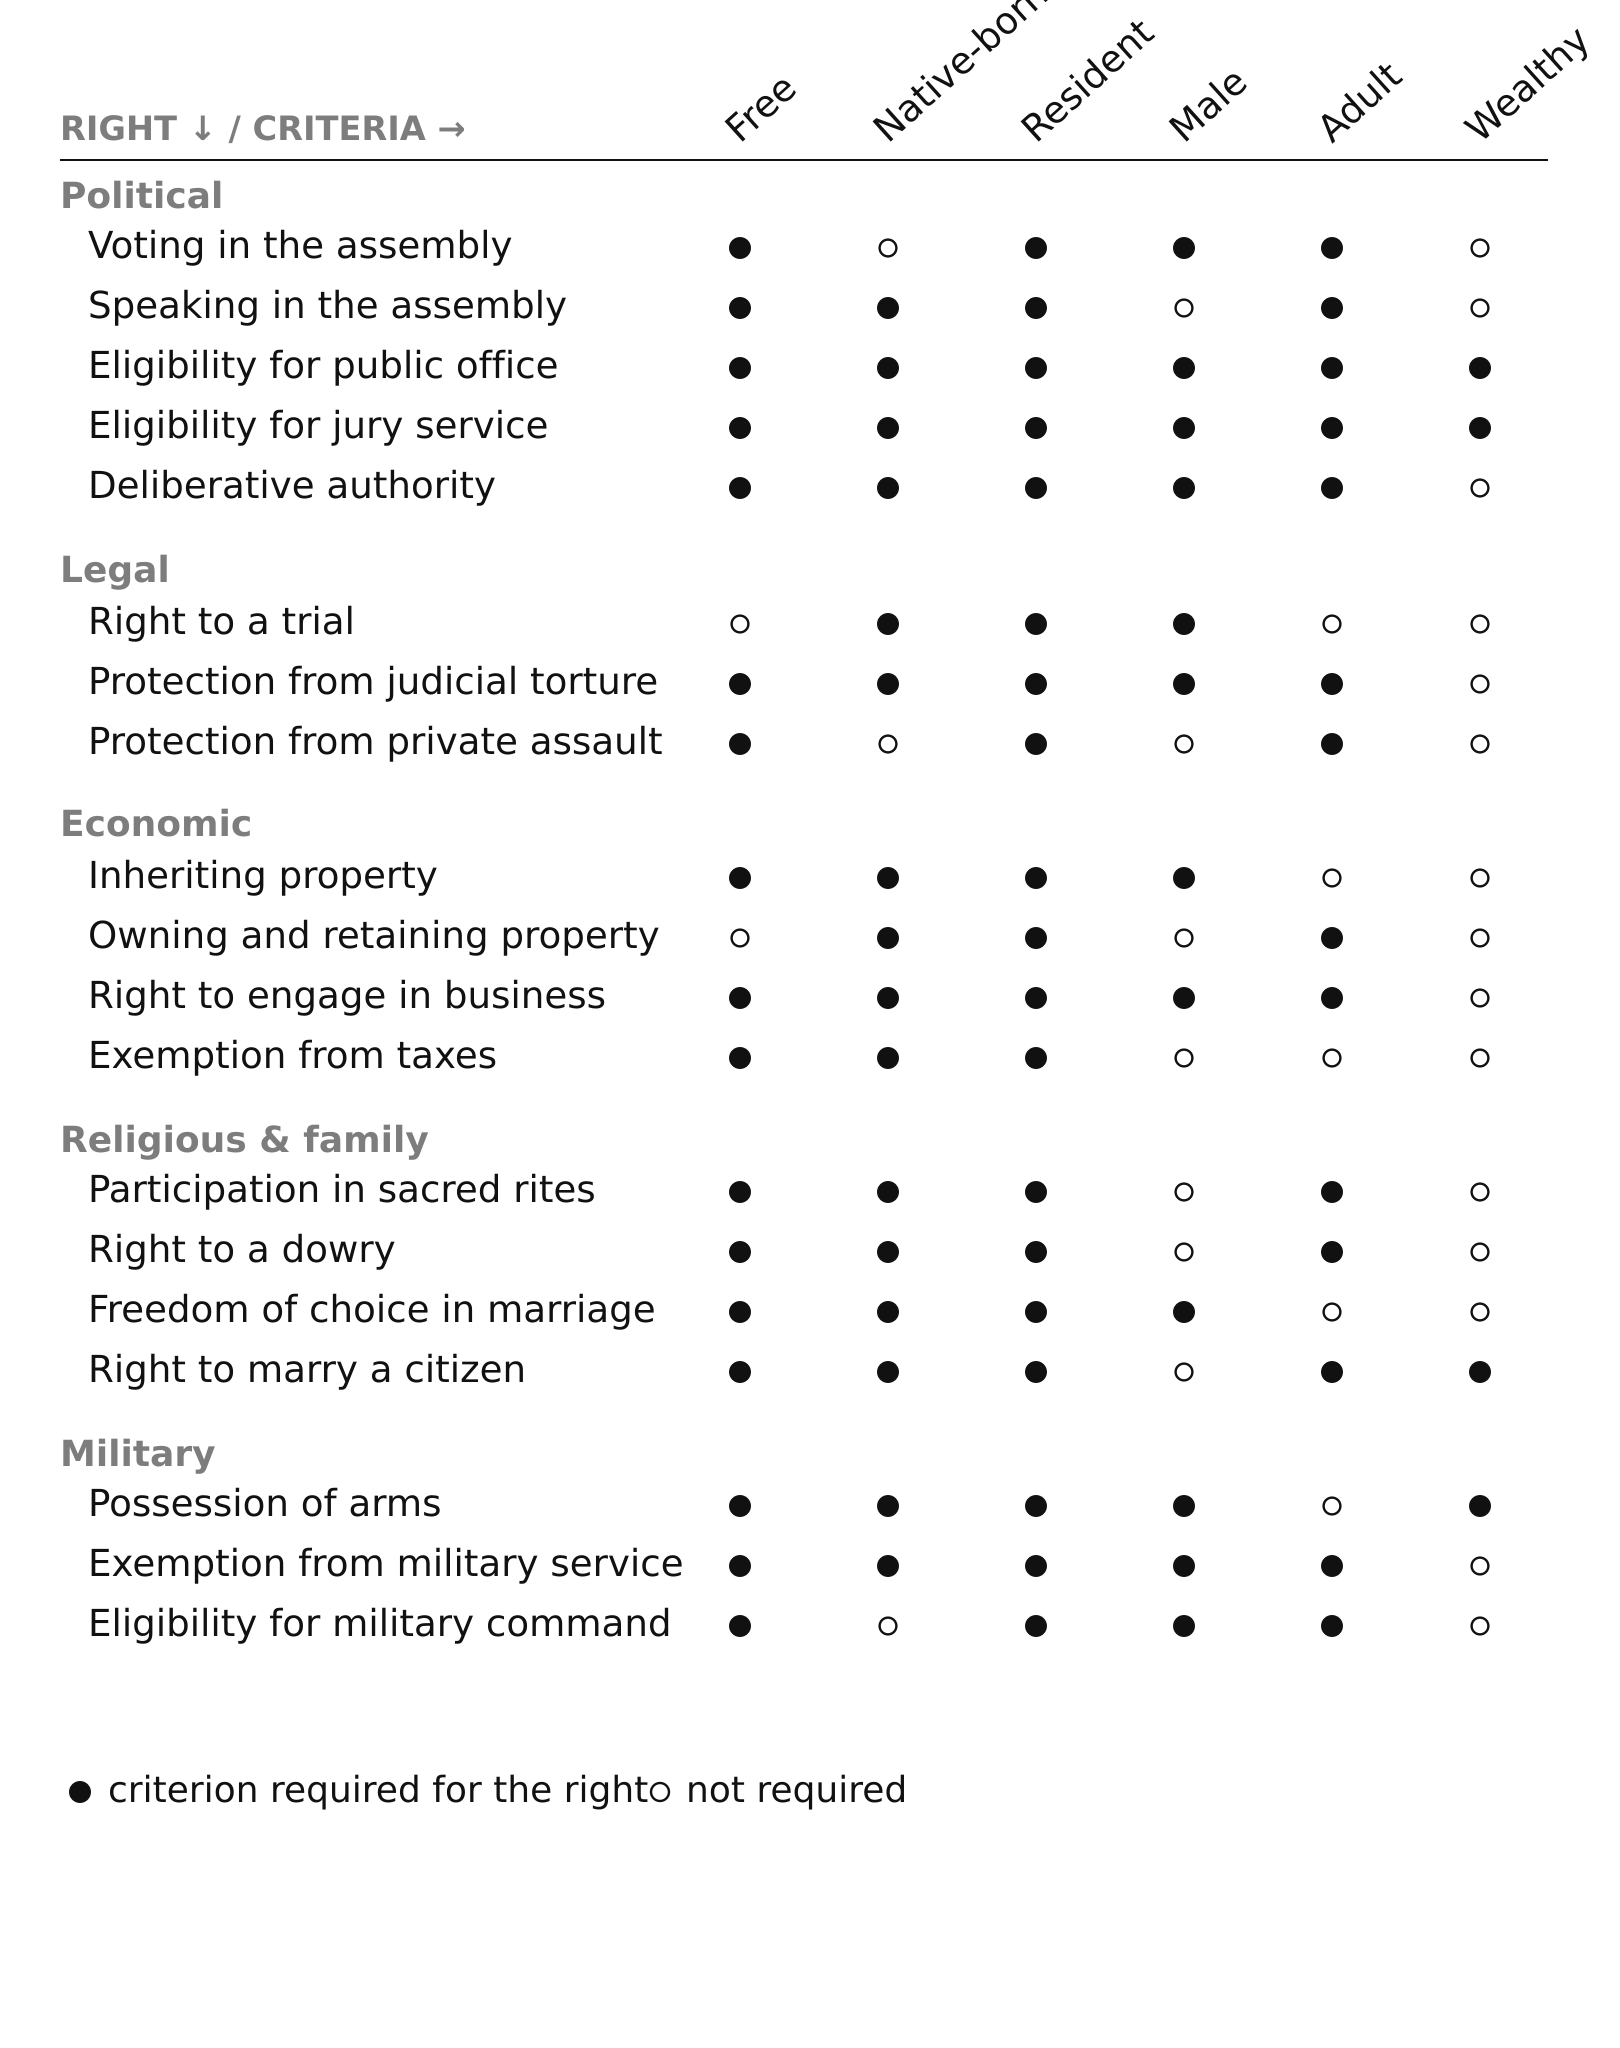

In [10]:
def fig_table(with_criteria=False, font_scale=1.2):
    """Rights x criteria table (criteria-ranking chart removed).

    font_scale multiplies every font size (and row spacing) proportionally.
    """
    fs = font_scale
    xs = [400 + 74 * i for i in range(6)]
    body = [f'<text x="60" y="150" font-size="{14*fs:.1f}" font-weight="700" fill="{GREY}">RIGHT &#8595; / CRITERIA &#8594;</text>']
    for x, c in zip(xs, CRIT_ORDER):
        body.append(f'<text x="{x}" y="152" font-size="{15.5*fs:.1f}" transform="rotate(-42 {x} 152)">{c}</text>')
    body.append(f'<line x1="60" y1="160" x2="{xs[-1]+34}" y2="160" stroke="{INK}"/>')
    hy = 184
    for t in TYPES:
        body.append(f'<text x="60" y="{hy:.0f}" font-size="{15*fs:.1f}" font-weight="700" fill="{GREY}">{t.replace("&","&amp;")}</text>')
        ry = hy + 17 * fs
        for i in rights_of_type(t):
            body.append(f'<text x="74" y="{ry+5:.0f}" font-size="{15.5*fs:.1f}">{RIGHTS[i][1].replace("&","&amp;")}</text>')
            for x, c in zip(xs, CRIT_ORDER):
                if c in RIGHTS[i][2]:
                    body.append(f'<circle cx="{x}" cy="{ry:.0f}" r="5.5" fill="{INK}"/>')
                else:
                    body.append(f'<circle cx="{x}" cy="{ry:.0f}" r="4.2" fill="#fff" stroke="{INK}" stroke-width="1.2"/>')
            ry += 25 * fs
        hy = ry + 14 * fs
    bottom = hy
    body.append(f'<circle cx="70" cy="{bottom+36:.0f}" r="5.5" fill="{INK}"/>')
    body.append(f'<text x="84" y="{bottom+41:.0f}" font-size="{15*fs:.1f}">criterion required for the right</text>')
    body.append(f'<circle cx="360" cy="{bottom+36:.0f}" r="4.5" fill="#fff" stroke="{INK}" stroke-width="1.2"/>')
    body.append(f'<text x="373" y="{bottom+41:.0f}" font-size="{15*fs:.1f}">not required</text>')
    w, h = 810, bottom + 84
    return svg(w, h, "\n".join(body), vx=30, vy=80)

Image(png(fig_table()))

### Figure 3 (top-right): group descriptions and the overall rights Hasse

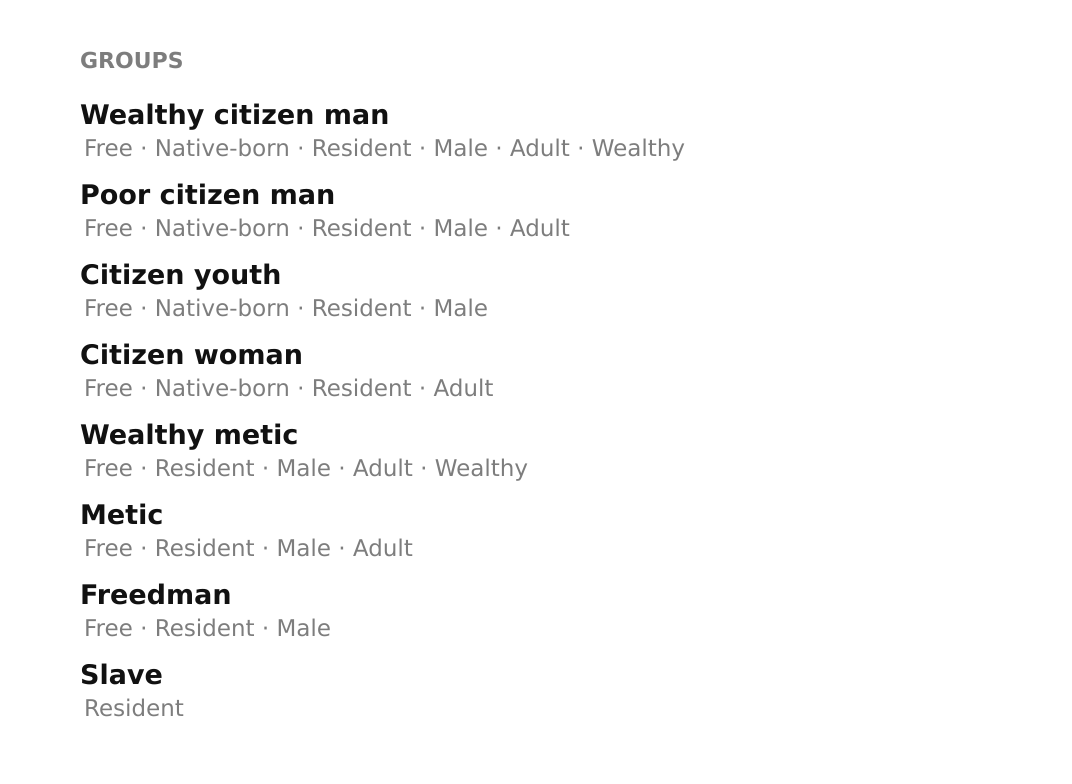

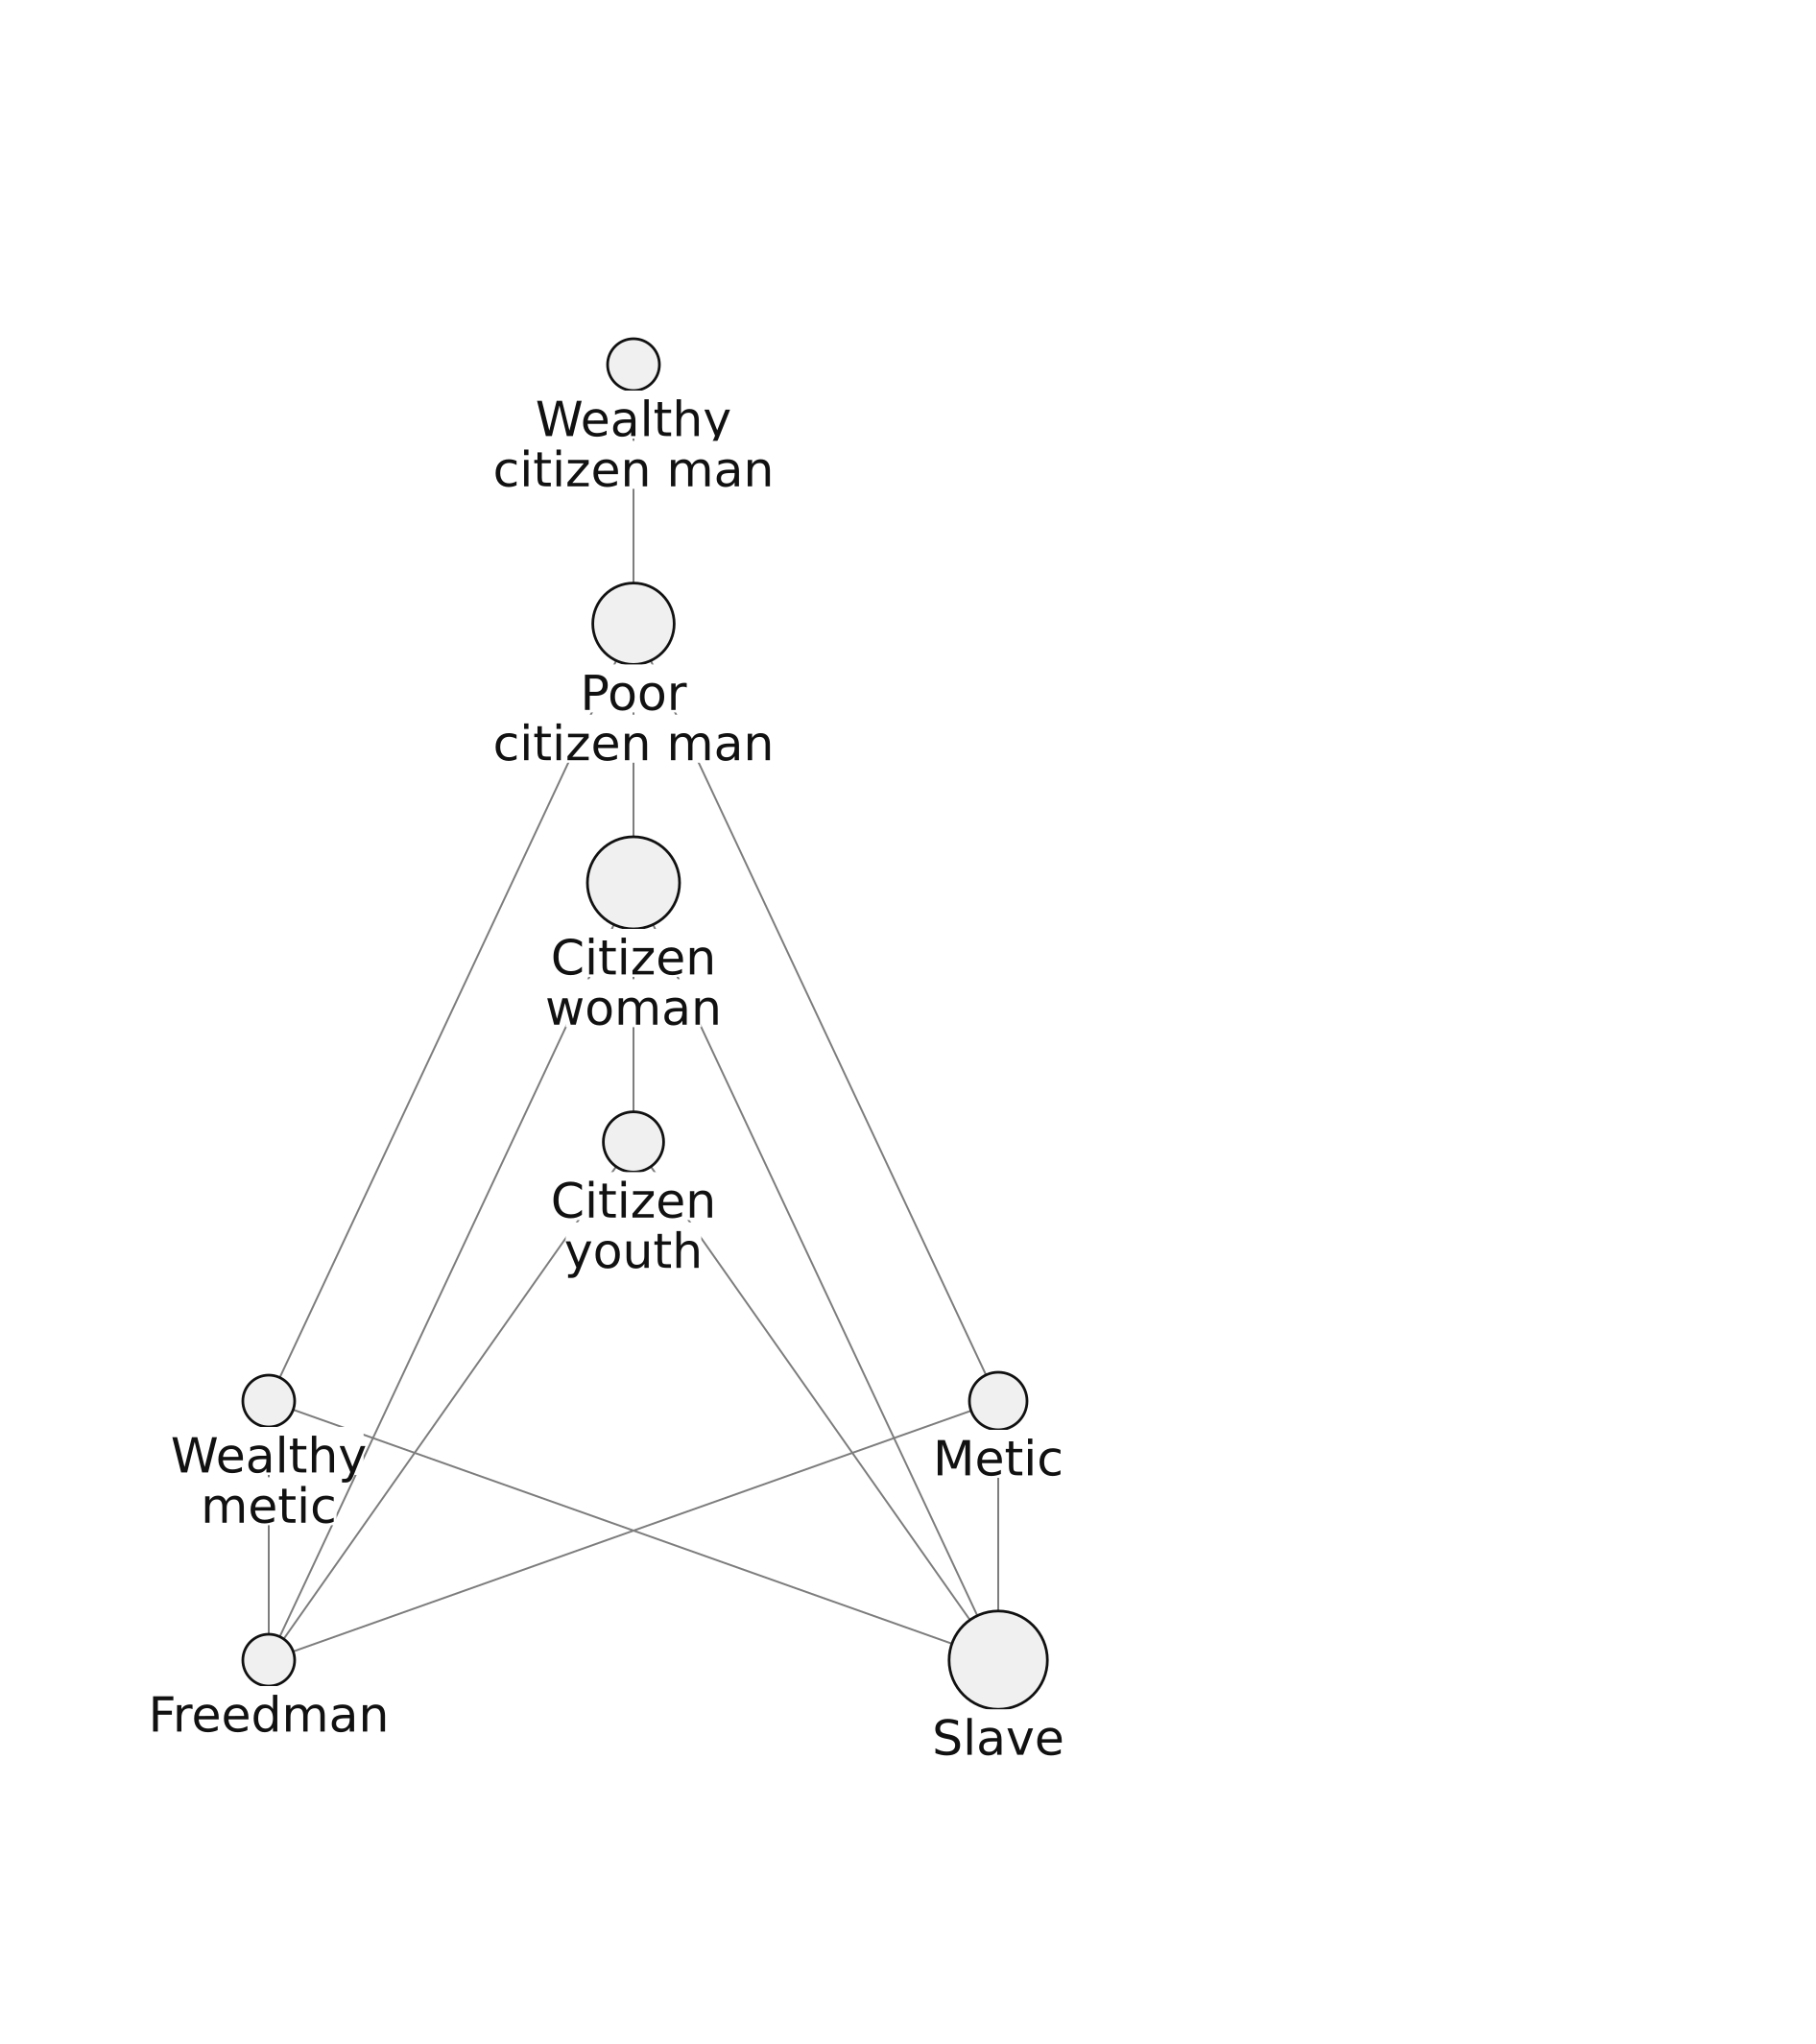

In [11]:
def fig_group_hasse(node_scale=1.5, text_scale=1.8, left_pad=140, vs=135, xs_gap=380):
    """Panel B of Figure 3: all-rights-combined Hasse of social groups.

    Same centered tier layout as the category panels (panel C), but over ALL rights:
    groups are stacked by the number of rights they hold, each tier centered, with
    straight covering edges. Node size ∝ population share.

    To make it more square:  raise  xs_gap  (wider)  and/or lower  vs  (less tall).
    """
    idxs = rights_of_type()
    hmap = {n: held(GROUPS[n], idxs) for n in GNAMES}
    s, x = type_panel(left_pad, 190, "", GNAMES, hmap,
                      radius=lambda n: node_scale * max(9.0, 1.35 * math.sqrt(POPULATION[n])),
                      split=lambda n: GROUP_SPLIT[n], vs=vs, xs_gap=xs_gap,
                      hy_off=0, label_fs=14 * text_scale, title_fs=1, label_inside=False)
    ntiers = len({len(hmap[n]) for n in GNAMES})
    H = 190 + (ntiers - 1) * vs + 200
    return svg(x, H, s)


def fig_group_list(text_scale=1.0):
    """The group descriptions (name + criteria met) as a standalone list."""
    name_fs, crit_fs, hdr_fs = 13.5 * text_scale, 11.5 * text_scale, 11 * text_scale
    row = 40 * text_scale
    gl = [f'<text x="40" y="34" font-size="{hdr_fs:.1f}" font-weight="700" fill="{GREY}">GROUPS</text>']
    gy, wmax = 62.0, 0.0
    for n in GNAMES:
        gl.append(f'<text x="40" y="{gy:.0f}" font-size="{name_fs:.1f}" font-weight="700">{n}</text>')
        cstr = " &#183; ".join(c for c in CRIT_ORDER if c in GROUPS[n]) or "&#8212; (none)"
        gl.append(f'<text x="42" y="{gy+16:.0f}" font-size="{crit_fs:.1f}" fill="{GREY}">{cstr}</text>')
        wmax = max(wmax, len(cstr) * crit_fs * 0.5)
        gy += row
    W = 42 + wmax + 40
    return svg(W, gy + 10, "\n".join(gl))


from IPython.display import display
display(Image(png(fig_group_list())))
display(Image(png(fig_group_hasse())))

### Figure 3 (middle): social groups ranked by rights held, one Hasse per category

In [12]:
held_counts

,Political,Legal,Economic,Religious & family,Military
Wealthy citizen man,5,3,4,4,3
Poor citizen man,3,3,4,3,2
Citizen youth,0,1,2,1,0
Citizen woman,1,1,2,2,0
Wealthy metic,1,1,0,0,1
Metic,1,1,0,0,1
Freedman,0,0,0,0,0
Slave,0,0,0,0,0


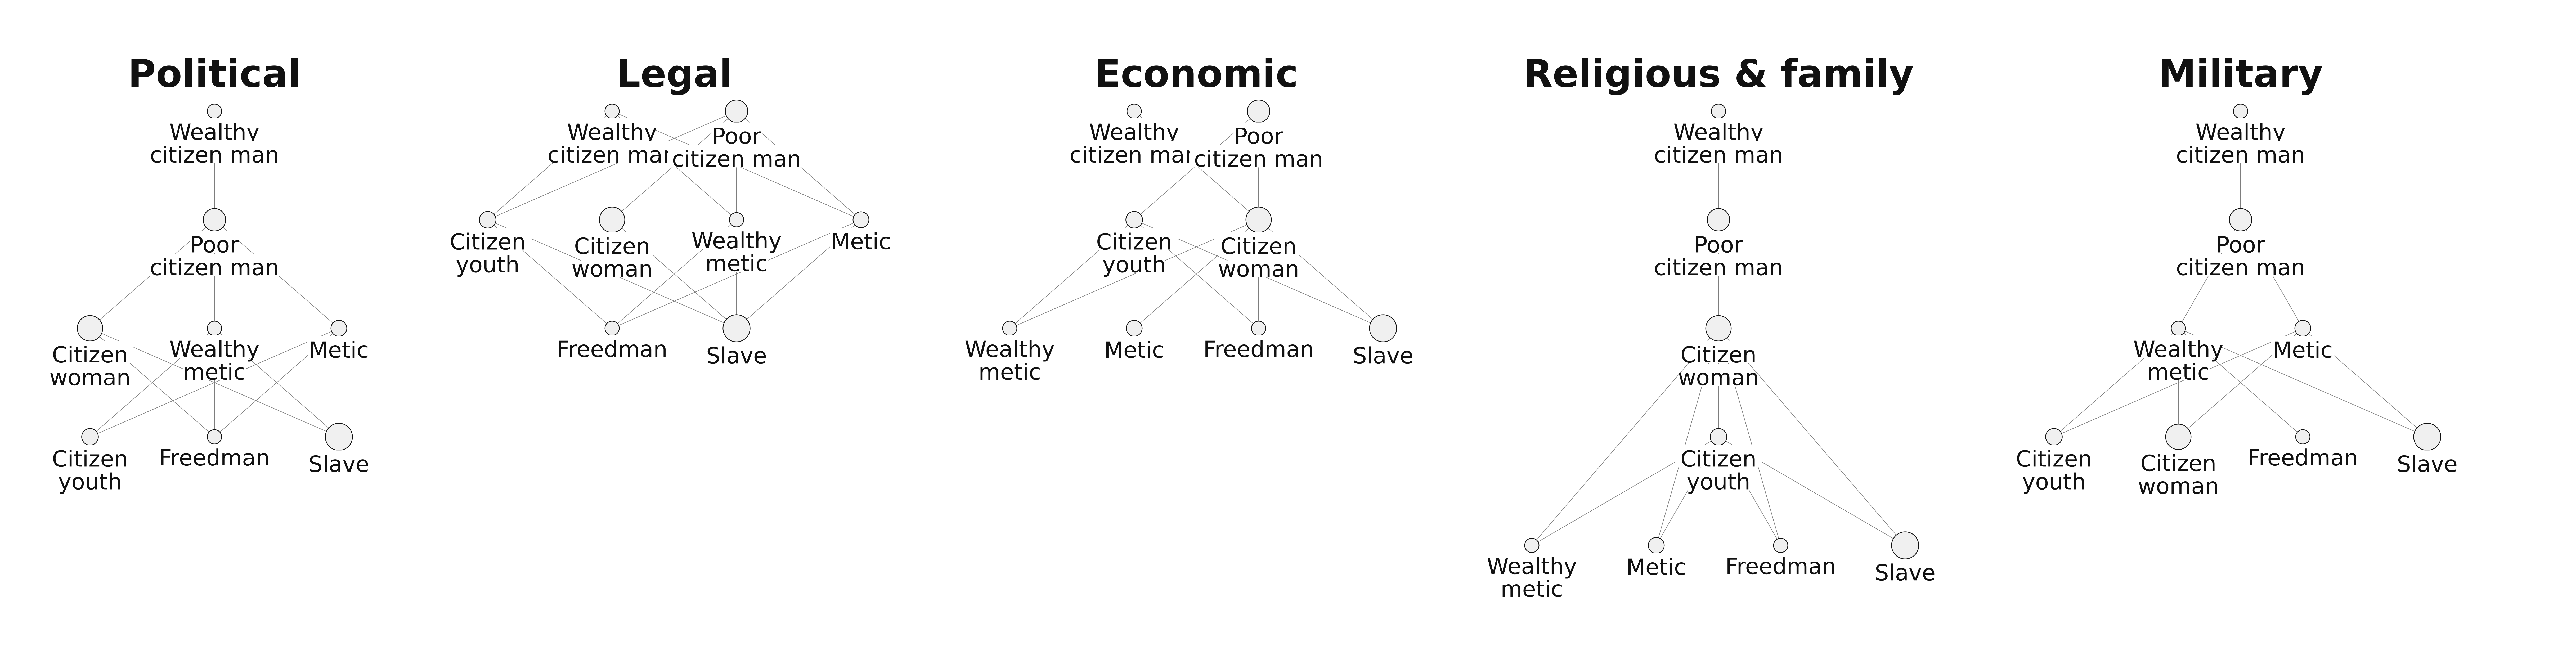

In [13]:
def fig_group_panels(node_scale=1.5, text_scale=2, left_pad=170):
    parts, x = [], left_pad
    for t in TYPES:
        idxs = rights_of_type(t)
        hmap = {n: held(GROUPS[n], idxs) for n in GNAMES}
        s, x = type_panel(x, 210, t, GNAMES, hmap,
                          radius=lambda n: node_scale * max(9.0, 1.35 * math.sqrt(POPULATION[n])),
                          split=lambda n: GROUP_SPLIT[n], vs=205, xs_gap=235,
                          hy_off=46, label_fs=14 * text_scale, title_fs=24 * text_scale,
                          label_inside=False)
        parts.append(s)
    return svg(x, 1220, "\n".join(parts))

Image(png(fig_group_panels(node_scale=1.5, text_scale=3)))

### Figure 3 (middle) as a 3 × 2 grid — one panel per rights category, plus *All rights*

Same social-group Hasse diagrams, laid out on a 3 × 2 grid: the first panel is *All rights*
(every right combined), followed by the five categories. The word "rights" is appended to each
panel title (*Political rights*, *Legal rights*, …). Node size still encodes population share.

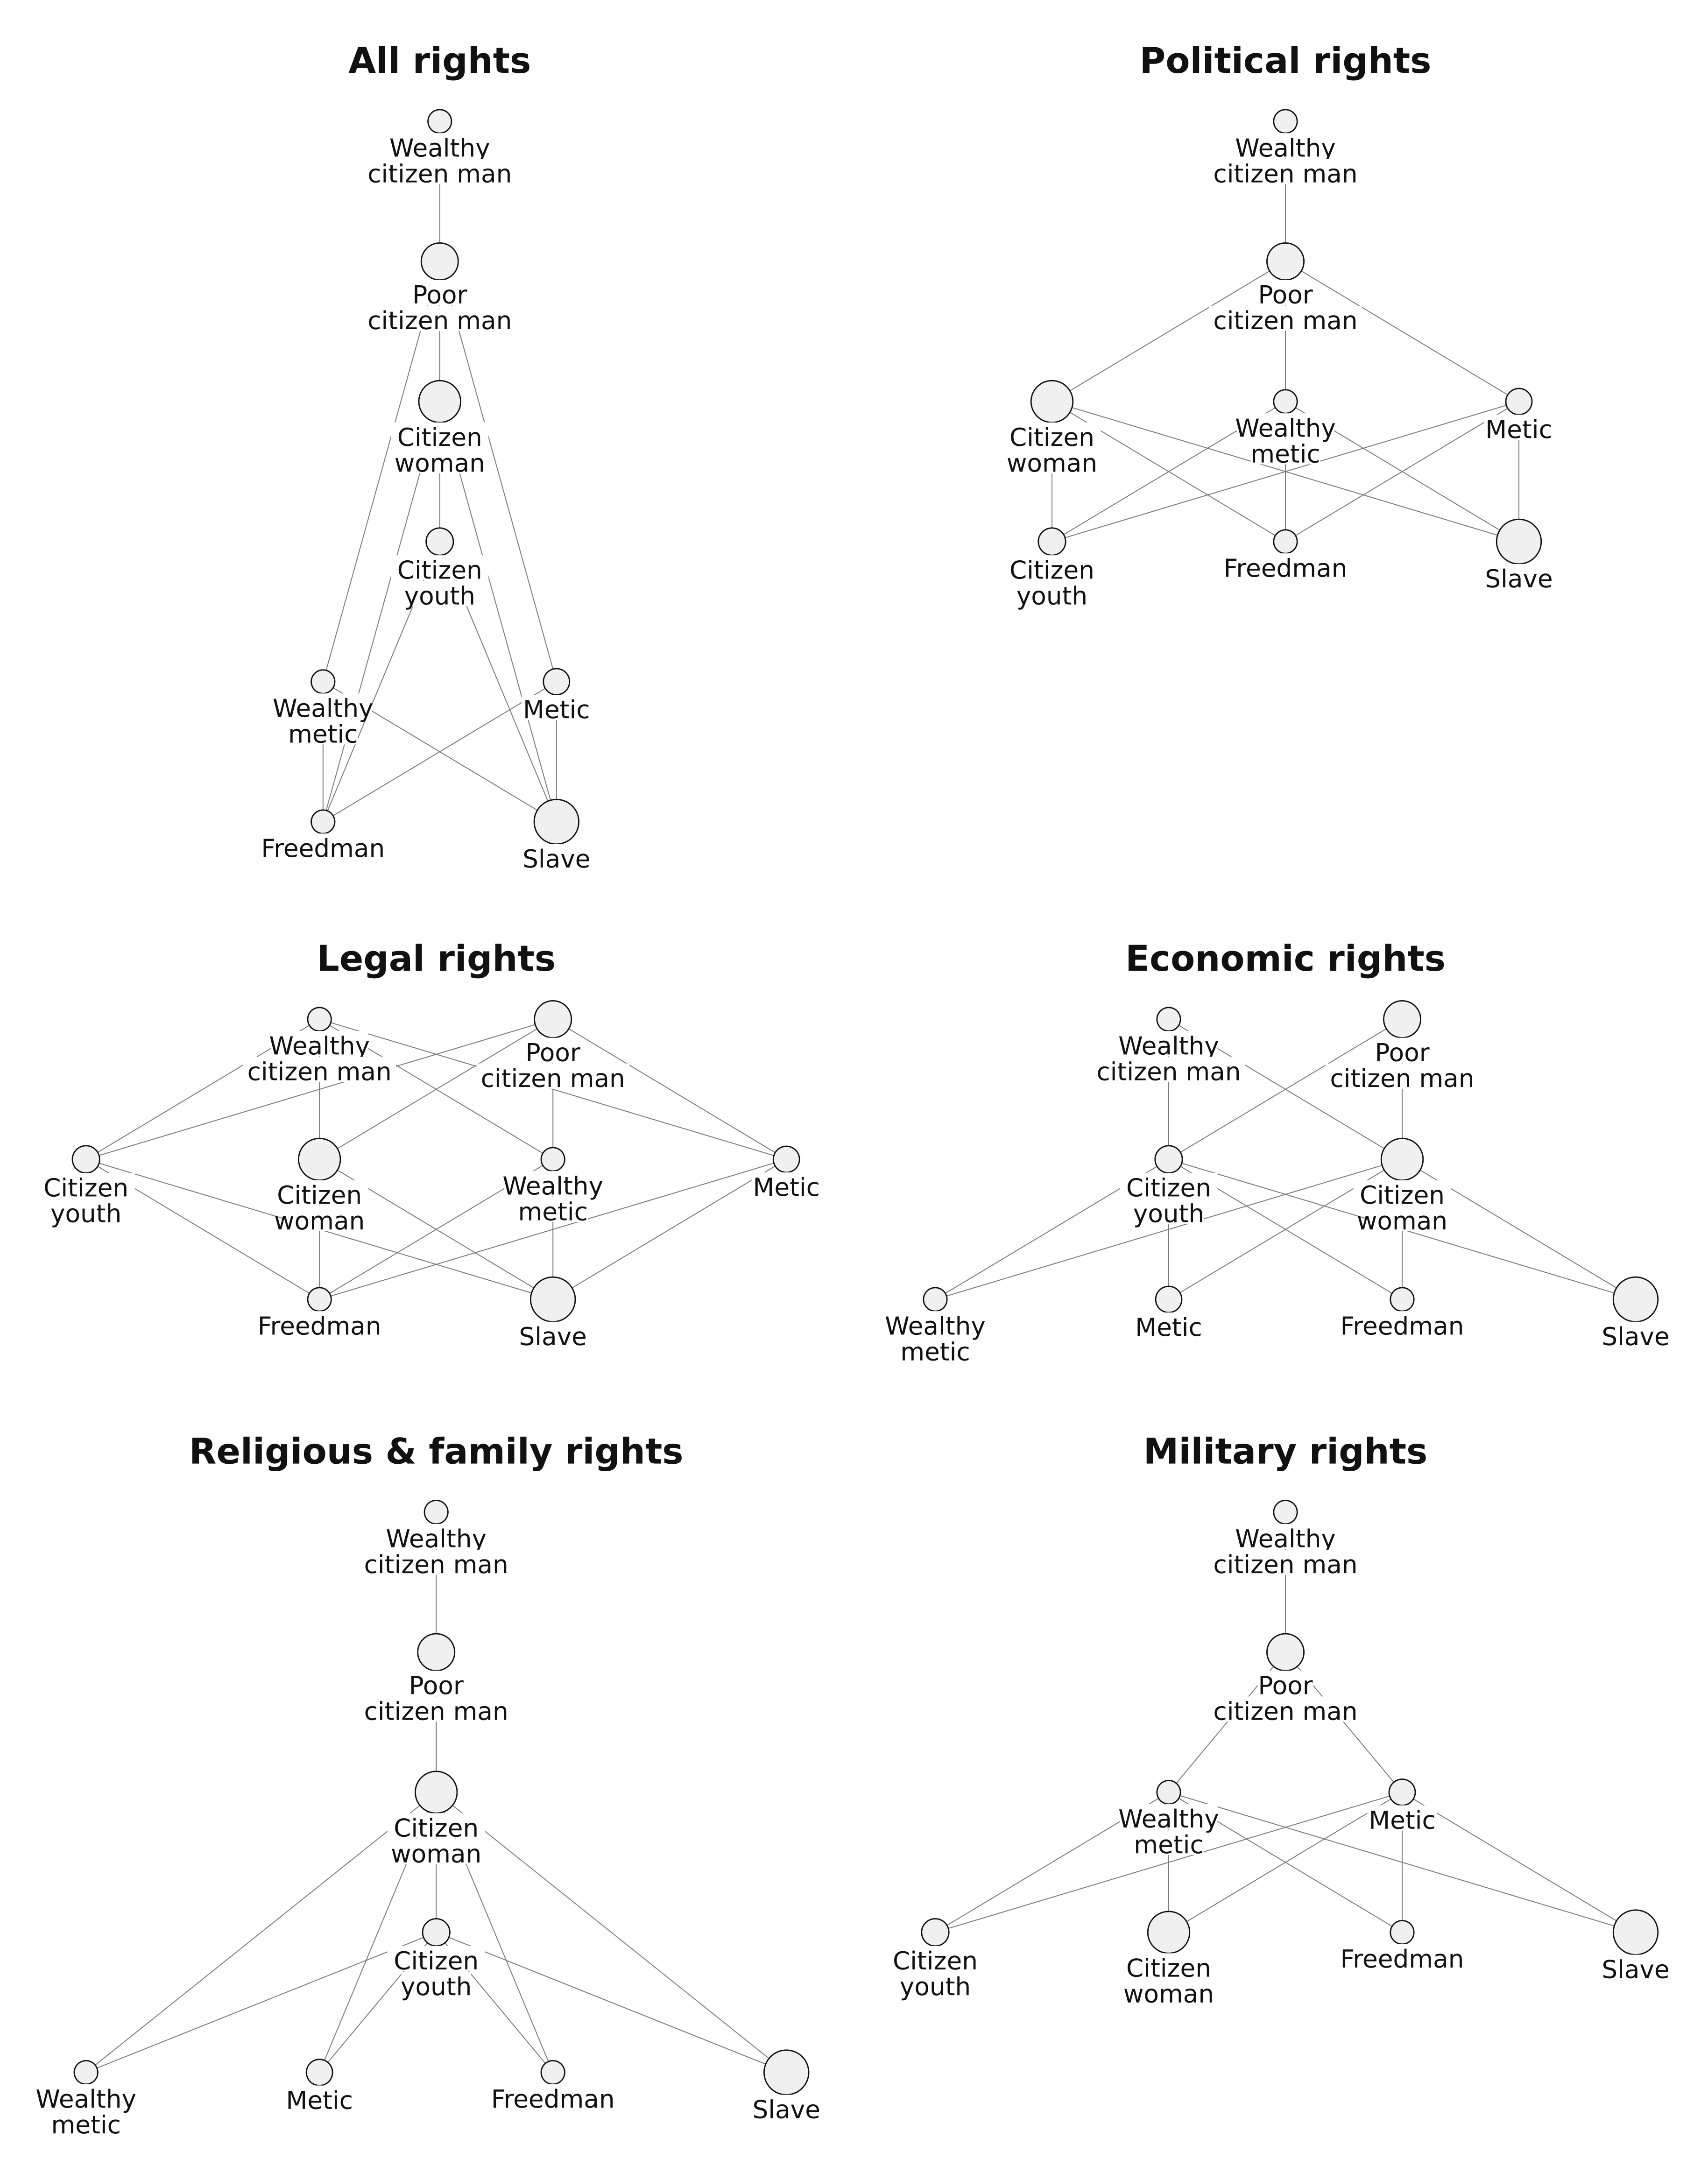

In [14]:
# Same group panels as a 3 x 2 grid: "All rights" first, then the five
# categories, with "rights" appended to every panel title. Reuses the helpers
# above; measures each panel's true bounding box so the grid never clips.
PANELS_3x2 = [(None, "All rights")] + [(t, f"{t} rights") for t in TYPES]


def _panel_with_bbox(top, title, hmap, radius, split, vs, xs_gap, hy_off, label_fs, title_fs):
    counts = sorted({len(hmap[n]) for n in GNAMES}, reverse=True)
    lvl = {c: i for i, c in enumerate(counts)}
    by = {}
    for n in GNAMES:
        by.setdefault(lvl[len(hmap[n])], []).append(n)
    maxk = max(len(v) for v in by.values())
    cx = (maxk - 1) * xs_gap / 2
    pos = {}
    for L, ns in by.items():
        k = len(ns)
        for i, n in enumerate(ns):
            pos[n] = (cx + (i - (k - 1) / 2) * xs_gap, top + L * vs)
    body = [f'<text x="{cx:.1f}" y="{top-hy_off:.0f}" font-size="{title_fs}" font-weight="700" '
            f'text-anchor="middle">{title.replace("&", "&amp;")}</text>']
    for hi, lo in covering(GNAMES, hmap):
        body.append(link(hi, lo, pos))
    x0 = x1 = cx
    y0, y1 = top - hy_off - title_fs, top
    title_half = len(title) * title_fs * 0.56 / 2
    x0, x1 = min(x0, cx - title_half), max(x1, cx + title_half)
    for n in GNAMES:
        px, py = pos[n]
        r = radius(n)
        lines = split(n)
        body.append(node(px, py, r, lines, fs=label_fs, stroke=1.4, inside=False))
        lbl_half = max((len(ln) for ln in lines), default=0) * label_fs * 0.56 / 2
        x0, x1 = min(x0, px - r, px - lbl_half), max(x1, px + r, px + lbl_half)
        y1 = max(y1, py + r + len(lines) * (label_fs + 1))
    return "\n".join(body), (x0, y0, x1, y1)


def fig_group_panels_3x2(node_scale=1.4, text_scale=1.9, vs=150, xs_gap=250,
                         top=140, cols=2, gutter=70, margin=40):
    def build(t, title):
        idxs = rights_of_type(t)
        hmap = {n: held(GROUPS[n], idxs) for n in GNAMES}
        return _panel_with_bbox(top, title, hmap,
                                radius=lambda n: node_scale * max(9.0, 1.35 * math.sqrt(POPULATION[n])),
                                split=lambda n: GROUP_SPLIT[n], vs=vs, xs_gap=xs_gap,
                                hy_off=52, label_fs=14 * text_scale, title_fs=20 * text_scale)

    panels = [build(t, title) for t, title in PANELS_3x2]
    rows = math.ceil(len(panels) / cols)
    pw = [x1 - x0 for _, (x0, _, x1, _) in panels]
    ph = [y1 - y0 for _, (_, y0, _, y1) in panels]
    col_w = [max(pw[i] for i in range(len(panels)) if i % cols == c) for c in range(cols)]
    row_h = [max(ph[i] for i in range(len(panels)) if i // cols == r) for r in range(rows)]
    col_x = [margin + sum(col_w[:c]) + c * gutter for c in range(cols)]
    row_y = [margin + sum(row_h[:r]) + r * gutter for r in range(rows)]
    parts = []
    for i, (body, (x0, y0, x1, y1)) in enumerate(panels):
        c, r = i % cols, i // cols
        dx = col_x[c] + (col_w[c] - pw[i]) / 2 - x0
        dy = row_y[r] - y0
        parts.append(f'<g transform="translate({dx:.1f} {dy:.1f})">\n{body}\n</g>')
    W = 2 * margin + sum(col_w) + (cols - 1) * gutter
    H = 2 * margin + sum(row_h) + (rows - 1) * gutter
    return svg(W, H, "\n".join(parts))


Image(png(fig_group_panels_3x2()))

### Figure 3 (bottom): criteria ranked by the rights they gate, one Hasse per category

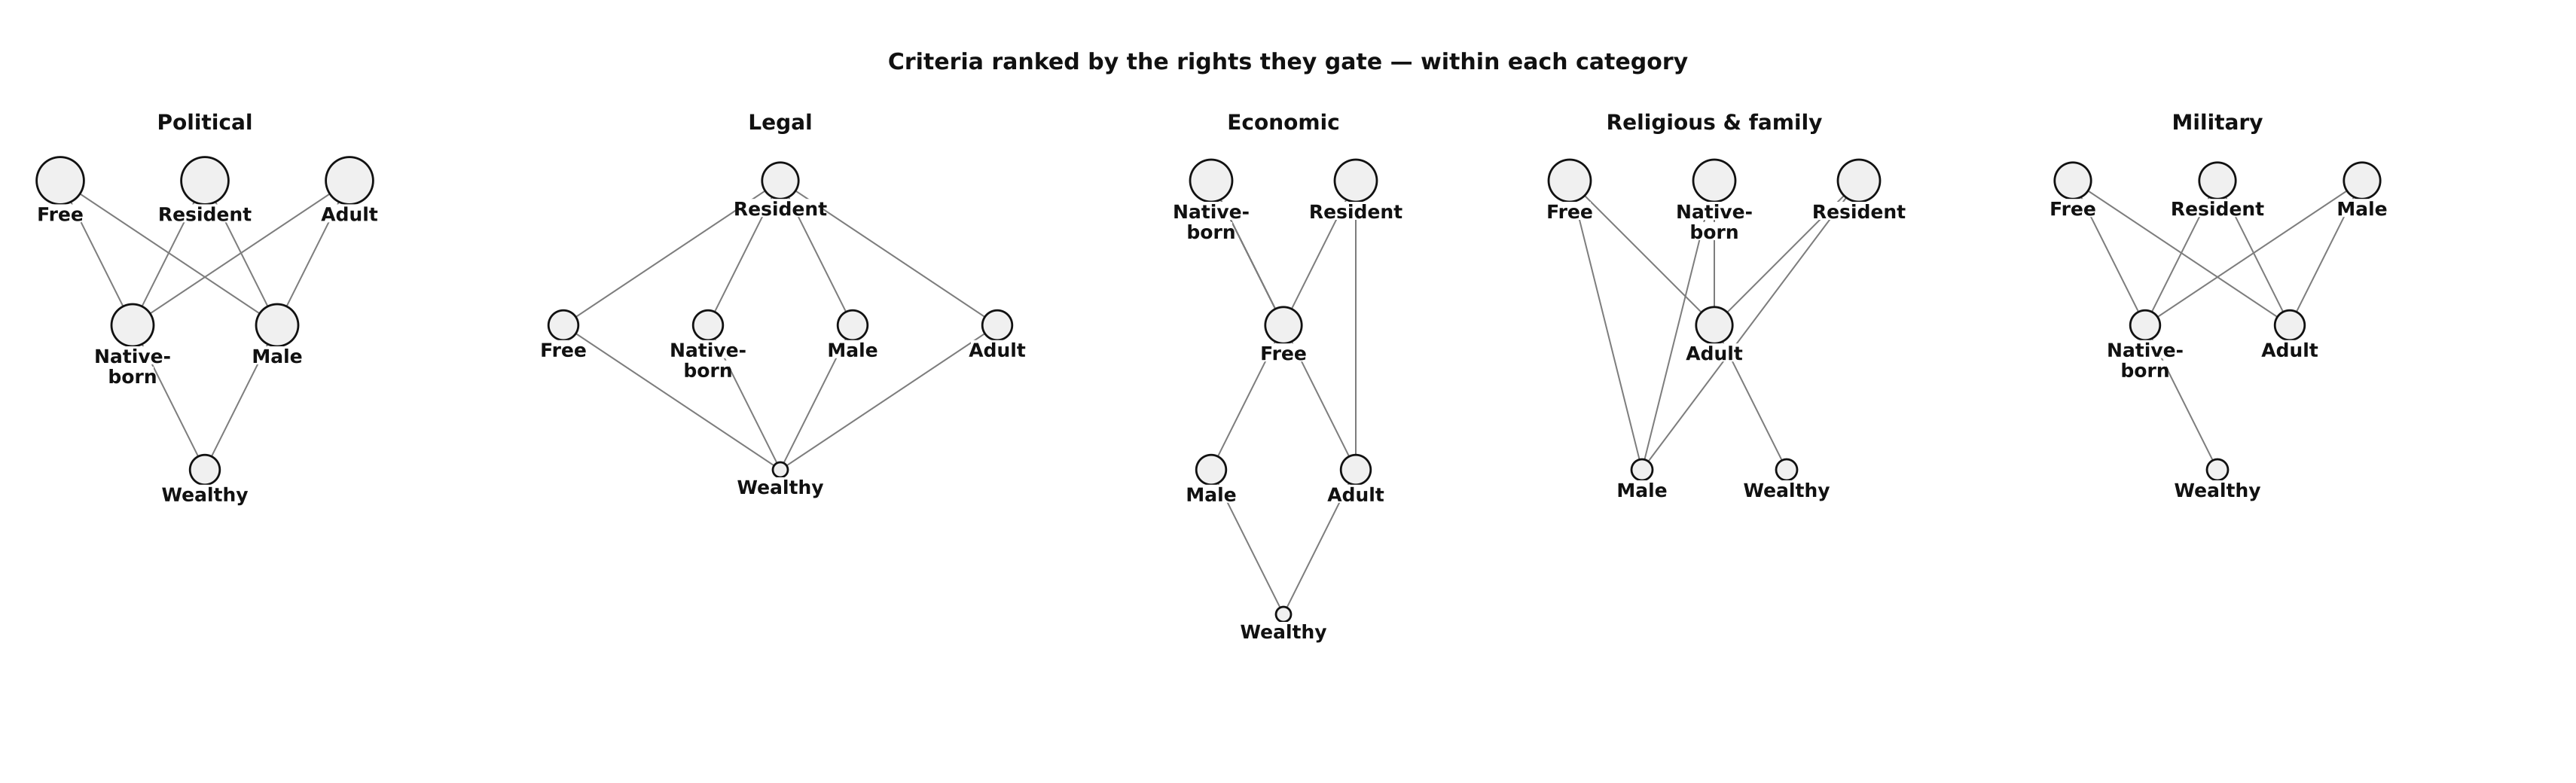

In [15]:
def fig_criteria_panels():
    parts, x = [], 40
    for t in TYPES:
        idxs = rights_of_type(t)
        gmap = {c: gated(c, idxs) for c in CRIT_ORDER}
        s, x = type_panel(x, 120, t, CRIT_ORDER, gmap,
                          radius=lambda c: max(5.0, 7 * math.sqrt(len(gmap[c]))),
                          split=lambda c: CRIT_SPLIT.get(c, [c]), vs=96, xs_gap=96, bold=True)
        parts.append(s)
    head = (f'<text x="{x//2}" y="46" font-size="15" font-weight="700" text-anchor="middle">'
            'Criteria ranked by the rights they gate &#8212; within each category</text>')
    return svg(x, 520, head + "\n" + "\n".join(parts))

Image(png(fig_criteria_panels()))

### Figure 3: composite (paper layout)

## Summary

One model drives every panel: the **table** fixes each right's required criteria; a group
holds a right iff its criteria contain that set; Hasse **edges** are the covering relations
of the subset order. Node size encodes magnitude only (rights gated for criteria, population
for groups). Everything is corpus-derived except the illustrative population prior.